# Laboratorium 8 - Równania Nieliniowe (Kompletne Rozwiązania)
Poniższy notatnik zawiera pełne realizacje Zadań 1, 2 oraz 3 zdefiniowanych w dokumencie `lab8.pdf`.

In [2]:
import numpy as np
import pandas as pd
import sympy as sp
from scipy.optimize import newton, bisect
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Zadanie 1. Rozwiązywanie równań nieliniowych (schematy iteracyjne)
Dane jest równanie $f(x) = x^2 - 3x + 2 = 0$. Mamy pierwiastek $\alpha=2$.
Badamy schematy:
1. $\phi_1(x) = (x^2 + 2)/3$
2. $\phi_2(x) = \sqrt{3x - 2}$
3. $\phi_3(x) = 3 - 2/x$
4. $\phi_4(x) = (x^2 - 2)/(2x - 3)$

In [2]:
x = sp.Symbol('x')
phi1 = (x**2 + 2)/3
phi2 = sp.sqrt(3*x - 2)
phi3 = 3 - 2/x
phi4 = (x**2 - 2)/(2*x - 3)

phis = [phi1, phi2, phi3, phi4]
alpha = 2

print("Analiza teoretyczna |phi'(2)| dla poszczególnych schematów:")
for i, p in enumerate(phis, 1):
    dp = sp.diff(p, x)
    val = abs(dp.subs(x, alpha))
    print(f"|phi_{i}'(2)| = {val} ", end="")
    if val > 1: print(" -> Rozbieżny")
    elif val > 0: print(" -> Zbieżny liniowo")
    else: print(" -> Zbieżny (co najmniej kwadratowo)")

Analiza teoretyczna |phi'(2)| dla poszczególnych schematów:
|phi_1'(2)| = 4/3  -> Rozbieżny
|phi_2'(2)| = 3/4  -> Zbieżny liniowo
|phi_3'(2)| = 1/2  -> Zbieżny liniowo
|phi_4'(2)| = 0  -> Zbieżny (co najmniej kwadratowo)



Wykonujemy po 10 iteracji ze wzorem startowym (np. $x_0 = 2.5$).
Obliczamy rzędy zbieżności za pomocą wzoru z instrukcji: $r = \frac{\ln(\epsilon_{k}/\epsilon_{k+1})}{\ln(\epsilon_{k-1}/\epsilon_{k})}$

In [3]:
def p1(x): return (x**2 + 2)/3
def p2(x): return np.sqrt(3*x - 2) if 3*x - 2 >= 0 else np.nan
def p3(x): return 3 - 2/x if x != 0 else np.nan
def p4(x): return (x**2 - 2)/(2*x - 3) if 2*x - 3 != 0 else np.nan

x0 = 2.5
funcs = [p1, p2, p3, p4]
results = {f"phi_{i}": [] for i in range(1, 5)}

for i, f in enumerate(funcs, 1):
    xk = x0
    results[f"phi_{i}"].append(xk)
    for _ in range(10):
        try:
            xk = f(xk)
        except:
            xk = np.nan
        results[f"phi_{i}"].append(xk)

df = pd.DataFrame(results)
df.index.name = "Iteracja"
print("Wartości x_k dla kolejnych iteracji:")
display(df)

def calc_r(iters, root=2.0):
    err = np.abs(np.array(iters) - root)
    r_vals = [np.nan] # Brak rzędu dla iteracji 0
    for k in range(1, len(err)-1):
        if err[k] == 0 or err[k+1] == 0 or err[k-1] == err[k]:
            r_vals.append(np.nan)
        else:
            num = np.log(err[k]/err[k+1])
            den = np.log(err[k-1]/err[k])
            r_vals.append(num/den if den != 0 else np.nan)
    r_vals.append(np.nan) # Brak rzędu dla ostatniej iteracji
    return r_vals

r_results = {}
for i in range(1, 5):
    r_results[f"r_phi_{i}"] = calc_r(df[f"phi_{i}"].values)

df_r = pd.DataFrame(r_results)
df_r.index.name = "Iteracja"
print("\nEksperymentalny rząd zbieżności r_k:")
display(df_r)

Wartości x_k dla kolejnych iteracji:


,phi_1,phi_2,phi_3,phi_4
Iteracja,,,,
0,2.500000e+00,2.500000,2.500000,2.500000
1,2.750000e+00,2.345208,2.200000,2.125000
2,3.187500e+00,2.244020,2.090909,2.012500
3,4.053385e+00,2.175330,2.043478,2.000152
4,6.143311e+00,2.127437,2.021277,2.000000
5,1.324676e+01,2.093397,2.010526,2.000000
6,5.915886e+01,2.068862,2.005236,2.000000
7,1.167257e+03,2.050997,2.002611,2.000000
8,4.541635e+05,2.037889,2.001304,2.000000



Eksperymentalny rząd zbieżności r_k:


,r_phi_1,r_phi_2,r_phi_3,r_phi_4
Iteracja,,,,
0,NaN,NaN,NaN,NaN
1,1.133346,0.936396,0.860488,1.660964
2,1.191732,0.952962,0.935496,1.913814
3,1.281875,0.965102,0.968892,1.994466
4,1.422474,0.974043,0.984714,1.943277
5,1.628059,0.980655,0.992422,NaN
6,1.854439,0.985560,0.996227,NaN
7,1.978701,0.989209,0.998118,NaN
8,1.999427,0.991929,0.999060,NaN


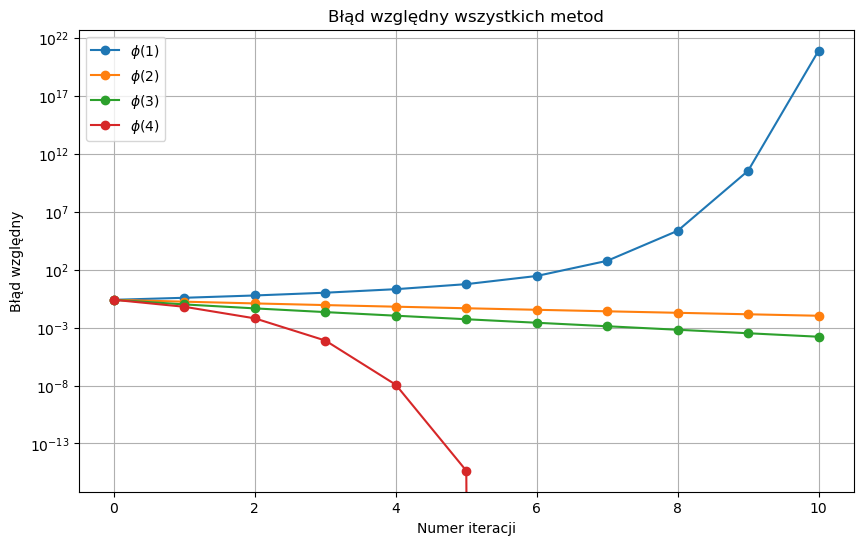

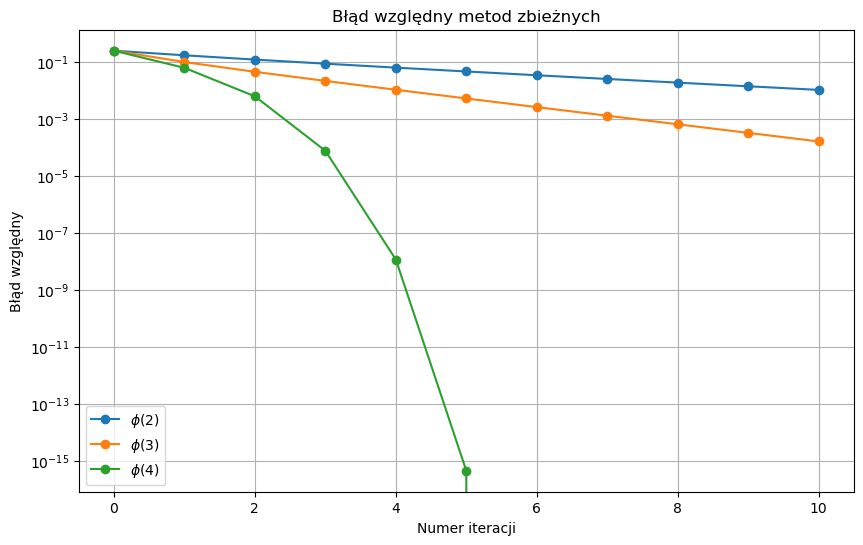

In [9]:

errors_rel = {}
for i in range(1, 5):
    column = f"phi_{i}"
    errors_rel[column] = np.abs(df[column].values - 2) / 2

plt.figure(figsize=(10, 6))
for i in range(1, 5):
    plt.semilogy(df.index, errors_rel[f"phi_{i}"], 'o-', label=f"$\phi$({i})")

plt.title("Błąd względny wszystkich metod")
plt.xlabel("Numer iteracji")
plt.ylabel("Błąd względny")
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for i in [2, 3, 4]:
    plt.semilogy(df.index, errors_rel[f"phi_{i}"], 'o-', label=f"$\phi$({i})")

plt.title("Błąd względny metod zbieżnych")
plt.xlabel("Numer iteracji")
plt.ylabel("Błąd względny")
plt.grid(True, which="both", ls="-")
plt.legend()
plt.show()

## Zadanie 2. Problemy metody Newtona
Sprawdzamy funkcje z punktami początkowymi, na których metoda Newtona zawodzi. Obliczamy pierwiastki inna metodą (bisekcja).

In [4]:
import numpy as np
from scipy.optimize import newton, bisect

def f1(x): return x**3 - 5*x
def df1(x): return 3*x**2 - 5
def f2(x): return x**3 - 3*x + 1
def df2(x): return 3*x**2 - 3
def f3(x): return 2 - x**5
def df3(x): return -5*x**4
def f4(x): return x**4 - 4.29*x**2 - 5.29
def df4(x): return 4*x**3 - 8.58*x

tasks = [
    ("a) x^3 - 5x", f1, df1, 1.0, -1, 1),
    ("b) x^3 - 3x + 1", f2, df2, 1.0, 0, 1),
    ("c) 2 - x^5", f3, df3, 0.01, 0, 2),
    ("d) x^4 - 4.29x^2 - 5.29", f4, df4, 0.8, 2, 3)
]

for name, f, df, x0, a, b in tasks:
    print(f"--- Równanie: {name}, pierwotne x0 = {x0} ---")
    try:
        # 1. Próba znalezienia pierwiastka dla zadanego x0
        res_newton = newton(f, x0, fprime=df, maxiter=50)
        print(f"  [Newton] Sukces : {res_newton}")
    except Exception as e:
        print(f"  [Newton] Błąd dla x0={x0}: {e}")
        
        # 2. Zmodyfikowanie wywołania newton() (zmiana punktu startowego na prawy kraniec przedziału 'b')
        x0_mod = b 
        try:
            res_newton_mod = newton(f, x0_mod, fprime=df, maxiter=50)
            print(f"  [Newton Modyfikacja] Sukces po zmianie punktu startowego na x0={x0_mod}: {res_newton_mod}")
        except Exception as e2:
            print(f"  [Newton Modyfikacja] Błąd po zmianie punktu startowego: {e2}")
            
            # 3. Jeśli modyfikacja nie pomoże, używamy innej metody (bisekcji)
            res_bisect = bisect(f, a, b)
            print(f"  [Bisekcja] Znaleziony pierwiastek w przedziale [{a}, {b}]: {res_bisect}")
    print()

--- Równanie: a) x^3 - 5x, pierwotne x0 = 1.0 ---
  [Newton] Błąd dla x0=1.0: Failed to converge after 50 iterations, value is 1.0.
  [Newton Modyfikacja] Błąd po zmianie punktu startowego: Failed to converge after 50 iterations, value is 1.0.
  [Bisekcja] Znaleziony pierwiastek w przedziale [-1, 1]: 0.0

--- Równanie: b) x^3 - 3x + 1, pierwotne x0 = 1.0 ---
  [Newton] Błąd dla x0=1.0: Derivative was zero. Failed to converge after 1 iterations, value is 1.0.
  [Newton Modyfikacja] Błąd po zmianie punktu startowego: Derivative was zero. Failed to converge after 1 iterations, value is 1.0.
  [Bisekcja] Znaleziony pierwiastek w przedziale [0, 1]: 0.3472963553340378

--- Równanie: c) 2 - x^5, pierwotne x0 = 0.01 ---
  [Newton] Błąd dla x0=0.01: Failed to converge after 50 iterations, value is 713.6238464957056.
  [Newton Modyfikacja] Sukces po zmianie punktu startowego na x0=2: 1.148698354997035

--- Równanie: d) x^4 - 4.29x^2 - 5.29, pierwotne x0 = 0.8 ---
  [Newton] Błąd dla x0=0.8: Fail

## Zadanie 3. Wyprowadzenie schematów dla dodawania, mnożenia i dzielenia przez 2
Dla stałej $c > 0$ wyliczamy wartości korzystając z metody Newtona poddanej modyfikacjom dozwolonych instrukcji.

a) Wartość $1/c$: Funkcja $f(x) = 1/x - c = 0$. $f'(x) = -1/x^2$.
Wzór Newtona: $x_{n+1} = x_n - \frac{1/x_n - c}{-1/x_n^2} = x_n + x_n^2(1/x_n - c) = x_n(2 - c \cdot x_n)$

b) Wartość $1/\sqrt{c}$: Funkcja $f(x) = 1/x^2 - c = 0$. $f'(x) = -2/x^3$.
Wzór Newtona: $x_{n+1} = x_n - \frac{1/x_n^2 - c}{-2/x_n^3} = x_n + \frac{x_n^3}{2}(1/x_n^2 - c) = \frac{x_n}{2} (3 - c \cdot x_n^2)$

c) Wartość $\sqrt{c}$ (Metoda Herona): Funkcja $f(x) = x^2 - c = 0$. $f'(x) = 2x$.
Wzór Herona: $x_{n+1} = \frac{1}{2}(x_n + \frac{c}{x_n})$. Wada: Wymaga ogólnego dzielenia.

d) Wartość $\sqrt{c}$ bez ogólnego dzielenia:
Wystarczy wyliczyć $1/\sqrt{c}$ sposobem (b), a następnie pomnożyć wynik przez $c$ (ponieważ $c \cdot \frac{1}{\sqrt{c}} = \sqrt{c}$).

In [5]:
def calc_1_over_c(c, x0, iters=15):
    x = x0
    for _ in range(iters): x = x * (2 - c * x)
    return x

def calc_1_over_sqrt_c(c, x0, iters=15):
    x = x0
    for _ in range(iters): x = (x / 2.0) * (3 - c * x**2)
    return x

def calc_sqrt_heron(c, x0, iters=15):
    x = x0
    for _ in range(iters): x = 0.5 * (x + c / x)
    return x

def calc_sqrt_no_div(c, x0, iters=15):
    y = calc_1_over_sqrt_c(c, x0, iters)
    return c * y

c_val = 5.0
print(f"Testowanie algorytmów z zadania 3 dla stałej c = {c_val}\n")

print("a) 1/c")
print(f"   Dokładnie: {1/c_val}")
print(f"   Obliczone: {calc_1_over_c(c_val, x0=0.1)}\n")

print("b) 1/sqrt(c)")
print(f"   Dokładnie: {1/np.sqrt(c_val)}")
print(f"   Obliczone: {calc_1_over_sqrt_c(c_val, x0=0.1)}\n")

print("c) sqrt(c) - Heron")
print(f"   Dokładnie: {np.sqrt(c_val)}")
print(f"   Obliczone: {calc_sqrt_heron(c_val, x0=2.0)}\n")

print("d) sqrt(c) - Bez dzielenia (korzystając z b i pomnożenia przez c)")
print(f"   Dokładnie: {np.sqrt(c_val)}")
print(f"   Obliczone: {calc_sqrt_no_div(c_val, x0=0.1)}")

Testowanie algorytmów z zadania 3 dla stałej c = 5.0

a) 1/c
   Dokładnie: 0.2
   Obliczone: 0.19999999999999998

b) 1/sqrt(c)
   Dokładnie: 0.4472135954999579
   Obliczone: 0.4472135954999579

c) sqrt(c) - Heron
   Dokładnie: 2.23606797749979
   Obliczone: 2.23606797749979

d) sqrt(c) - Bez dzielenia (korzystając z b i pomnożenia przez c)
   Dokładnie: 2.23606797749979
   Obliczone: 2.23606797749979


# Zadanie 4

In [ ]:

def F(x):
    return np.array([
        x[0]**2 + x[1]**2 - 1,
        x[0]**2 - x[1]
    ])

def J(x):
    return np.array([
        [2*x[0], 2*x[1]],
        [2*x[0], -1]
    ])

x2_exact = (np.sqrt(5) - 1) / 2
x1_exact = np.sqrt(x2_exact)
exact_sol = np.array([x1_exact, x2_exact])

x_k = np.array([0.5, 0.5])
for i in range(10):
    delta = np.linalg.solve(J(x_k), -F(x_k))
    x_k = x_k + delta

print("--- Zadanie 4 ---")
print(f"Rozwiązanie numeryczne:  {x_k}")
print(f"Rozwiązanie dokładne:    {exact_sol}")

err_rel = np.linalg.norm(x_k - exact_sol) / np.linalg.norm(exact_sol)
print(f"Błąd względny: {err_rel:.2e}")